In [444]:
import nibabel as nib
import numpy as np
from skimage.filters import gaussian
from skimage.segmentation import active_contour
from skimage.measure import find_contours
from skimage.draw import polygon
import matplotlib.pyplot as plt
import os

# Example usage:
img_mri = nib.load('./MRI_Brain_T1mprage_1.nii')
img_seg = nib.load('./Segmentation2.nii')

vol_mri = img_mri.get_fdata()  # whole head
vol_seg = img_seg.get_fdata() # manually segmented cerebellum, with ITK-SNAP
vol_mri.shape  # 224,216,288
vol_seg.shape # 224,216,288 --> contains 290 zeros, and 1 one 



(224, 216, 288)

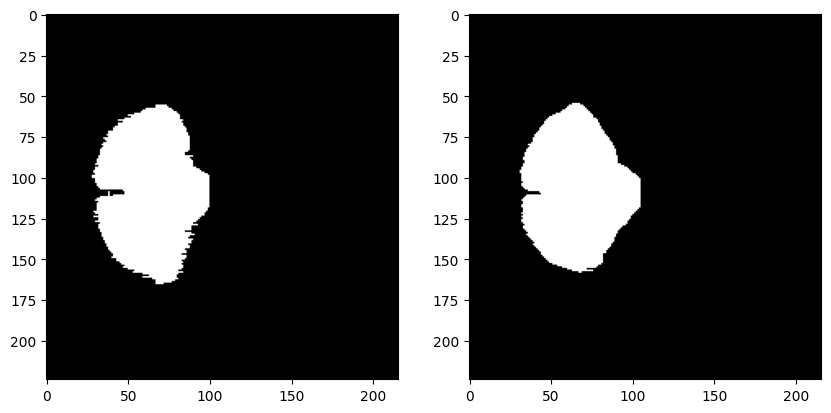

In [445]:
# PRE PROCESSING OF THE DATA
from skimage.morphology import remove_small_objects
from skimage.morphology import binary_closing
from skimage.morphology import remove_small_holes
from skimage.morphology import binary_erosion
from skimage.morphology import binary_dilation
from skimage.measure import label, regionprops_table
import pandas as pd

vol_binary = vol_seg > 0

## apply operations on the mask
m = remove_small_objects(vol_binary, min_size=5000,connectivity=1)

m = binary_closing(m)

m = remove_small_holes(m,1000,connectivity=1)

# dilatation to make to keep lost parts of the cerebellum
m = binary_dilation(m)


# NOW I WANT TO PRINT IN THE SLICE [;,;,120] THE ORIGINAL SLICE AND THE PRE-PROCESSED SLICE 
fig, ax = plt.subplots(1,2,figsize=(10,5))
ax[0].imshow(vol_seg[:,:,130], cmap='gray')
ax[1].imshow(m[:,:,139], cmap='gray')
plt.show()




In [453]:
# TAKE DATA
import numpy as np
import matplotlib.pyplot as plt
from skimage.morphology import remove_small_objects, binary_closing, remove_small_holes, binary_erosion
from skimage.measure    import label, regionprops
from skimage.segmentation import disk_level_set

# NOW LABLE THE SLICES 
labeled,num = label(m,background=0,return_num=True,connectivity=1)
# there is only one label
# which slices has cerebellum?
slices_with_cerebellum = []
for z in range(labeled.shape[2]):
    sl = labeled[:, :, z]
    if sl.sum() == 0:
        continue
    else:
        slices_with_cerebellum.append(z)
print(num)
print(slices_with_cerebellum)


1
[105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163]


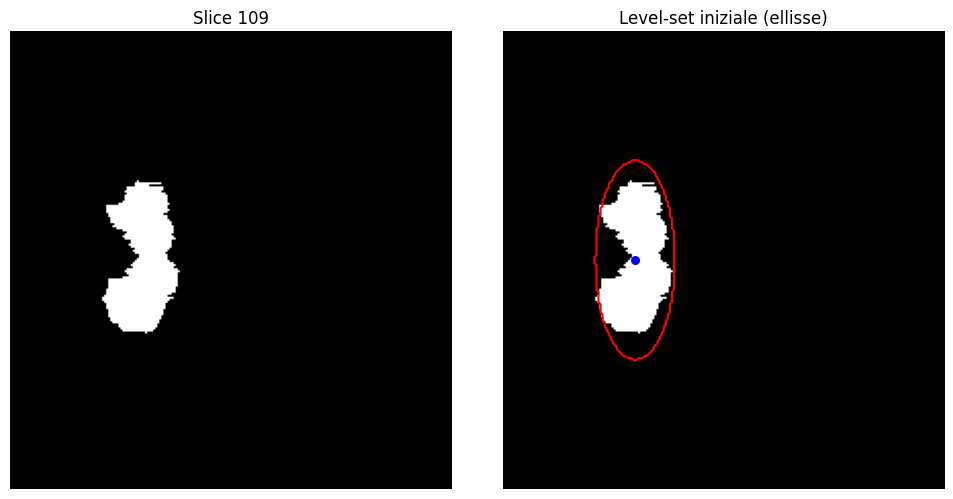

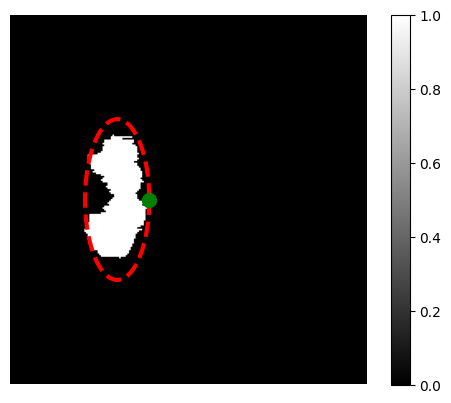

In [501]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.measure import regionprops

# 1) Estrai proprietà
slice_idx = 109
props = regionprops(labeled[:, :, slice_idx])
y0 = props[0].centroid[0]                      # centro y
x0 = props[0].centroid[1]                 # centro x (scala se necessario)
major_axis_length = props[0].major_axis_length *1.2
minor_axis_length = props[0].minor_axis_length *1.2

# 2) Semi-assi
ratio = 0.99
radius1 = (major_axis_length / 2.0) * ratio    # semiasse verticale (asse y)
radius2 = (minor_axis_length / 2.0) * ratio    # semiasse orizzontale (asse x)

# 3) Costruisci la level-set dell’ellisse
tmp = m[:, :, slice_idx]
h, w = tmp.shape
Y, X = np.ogrid[:h, :w]
# criterio ellisse: ((y - y0)/radius1)^2 + ((x - x0)/radius2)^2 <= 1
init_ls = (((Y - y0)**2) / radius1**2 + ((X - x0)**2) / radius2**2) <= 1
init_ls = init_ls.astype(float)

# 4) Visualizza immagine e contour
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(tmp, cmap='gray')
axes[0].set_title(f"Slice {slice_idx}")
axes[0].axis('off')

axes[1].imshow(tmp, cmap='gray')
axes[1].contour(init_ls, [0.5], colors='r')
axes[1].scatter([x0], [y0], c='b', s=30)
axes[1].set_title("Level-set iniziale (ellisse)")
axes[1].axis('off')

plt.tight_layout()
plt.show()

# 5) (Opzionale) traccia i punti di contorno parametrici
s = np.linspace(0, 2 * np.pi, 400)
r = y0 + radius1 * np.sin(s)
c = x0 + radius2 * np.cos(s)
init_pts = np.vstack([r, c]).T

plt.imshow(tmp, cmap='gray')
plt.plot(init_pts[:, 1], init_pts[:, 0], '--r', lw=3)
plt.plot(init_pts[0, 1], init_pts[0, 0], 'og', markersize=10)   # punto di partenza
plt.colorbar()
plt.axis('off')
plt.show()


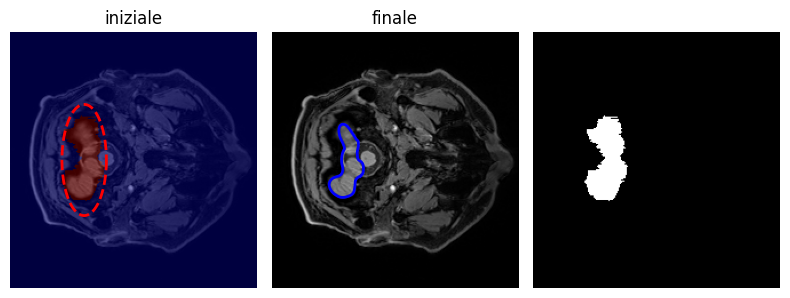

In [503]:
from skimage.filters import gaussian
from skimage.segmentation import inverse_gaussian_gradient, active_contour
import matplotlib.pyplot as plt




img = vol_mri[:, :, slice_idx]
mask = m[:, :, slice_idx].astype(bool)

# 2) azzera tutto ciò che è fuori dalla maschera
img_masked = img.copy()
img_masked[~mask] = 0

# 3) do that onlu inside the mask
img_f = gaussian(img_masked, sigma=2, preserve_range=False)

# 4) calcola l’indicatore di bordo
gimg = inverse_gaussian_gradient(img_f)


snake = active_contour(
    img_f,      # o prova gimg
    init_pts,
    alpha=50,      # elasticità
    beta=50,      # rigidità
    gamma=50,    # passo
    w_edge=1.5,   # forza sul bordo
)

# 4) plottalo
fig, axes = plt.subplots(1,3, figsize=(8,4))
# Primo subplot
axes[0].imshow(vol_mri[:,:,slice_idx], cmap='gray')
axes[0].imshow(m[:,:,slice_idx], cmap='jet', alpha=0.5)  # <-- aggiunto qui sopra il primo
axes[0].plot(init_pts[:,1], init_pts[:,0], 'r--', lw=2)
axes[0].set_title("iniziale")
# Secondo subplot
axes[1].imshow(vol_mri[:,:,slice_idx], cmap='gray')
axes[1].plot(snake[:,1], snake[:,0], 'b-',  lw=2)
axes[1].set_title("finale")
# Terzo subplot
axes[2].imshow(m[:,:,slice_idx], cmap='gray')
# Toglie assi
for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.show()

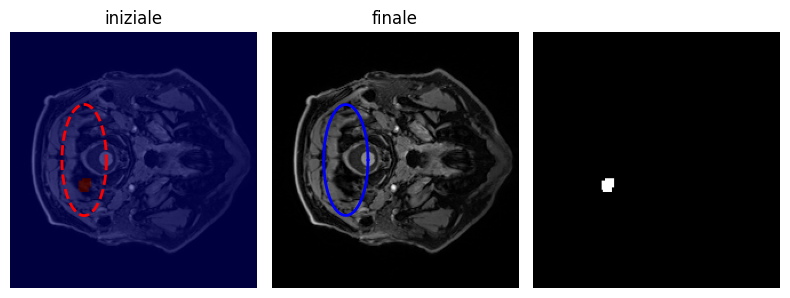

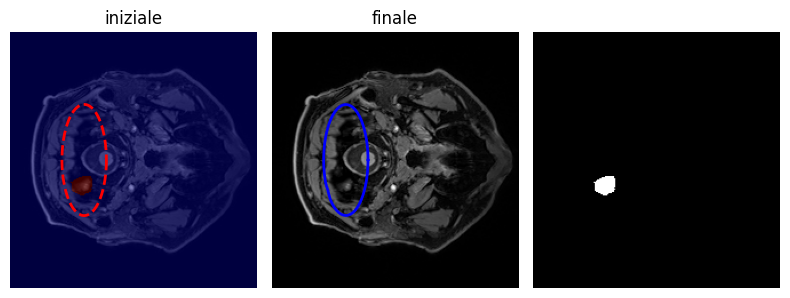

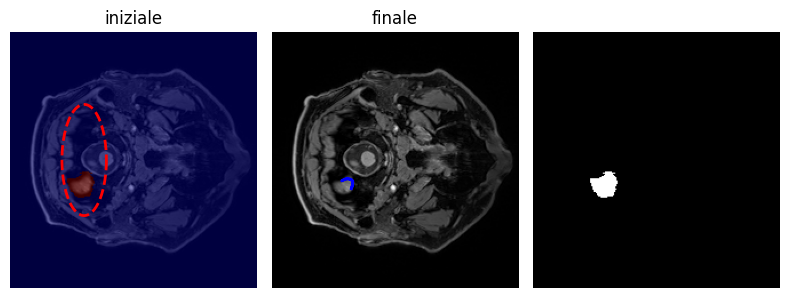

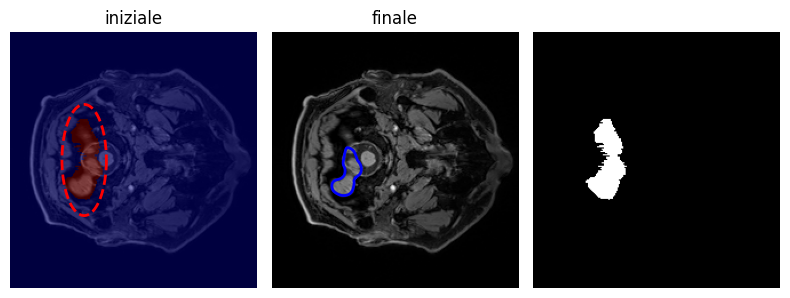

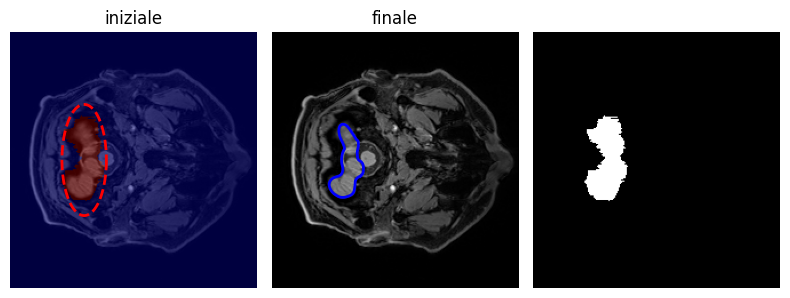

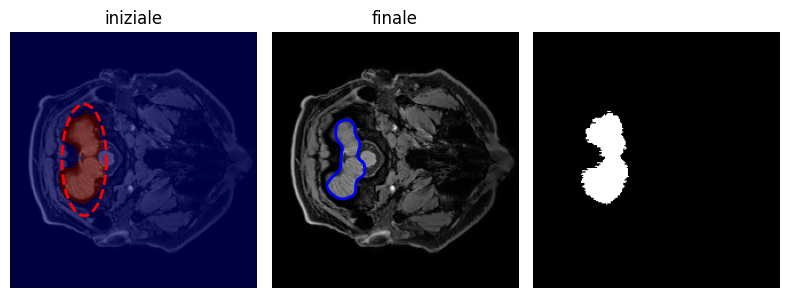

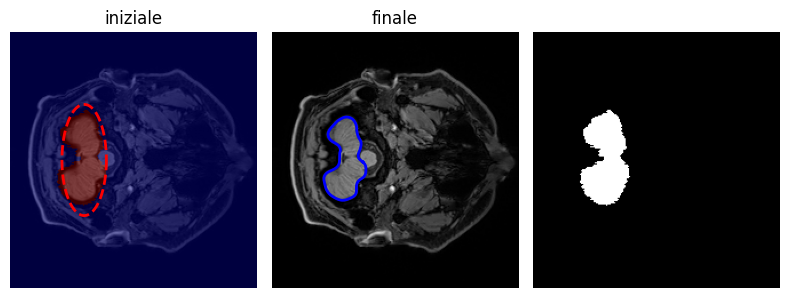

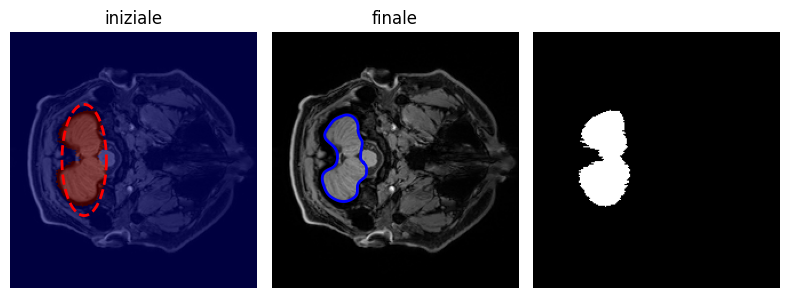

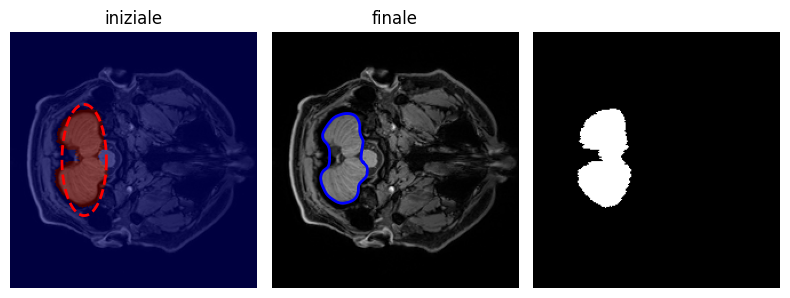

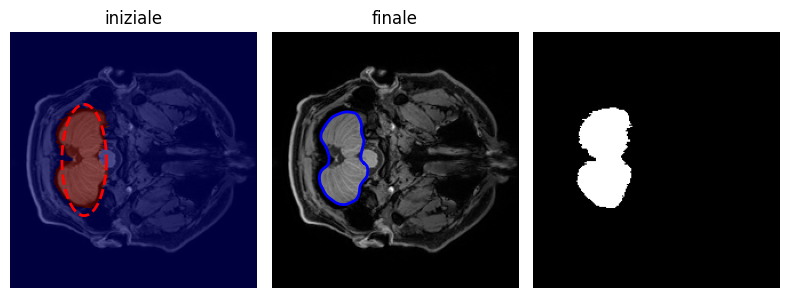

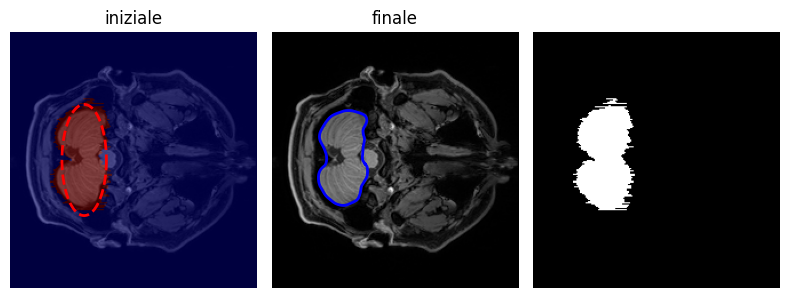

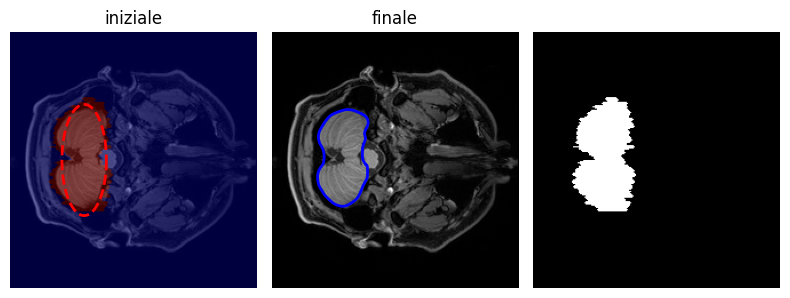

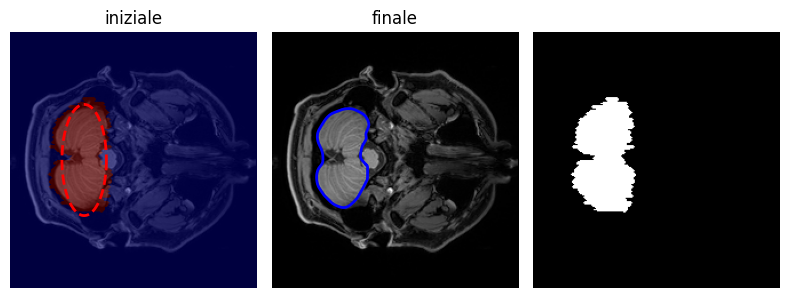

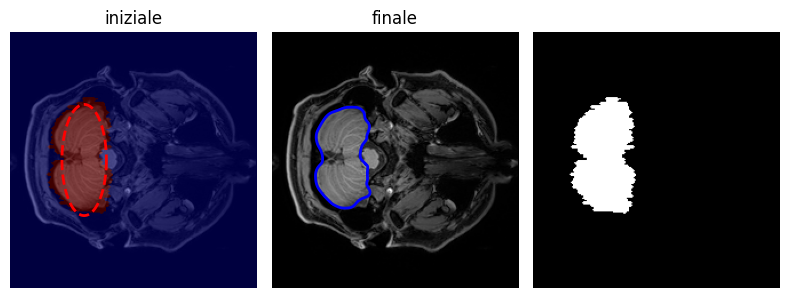

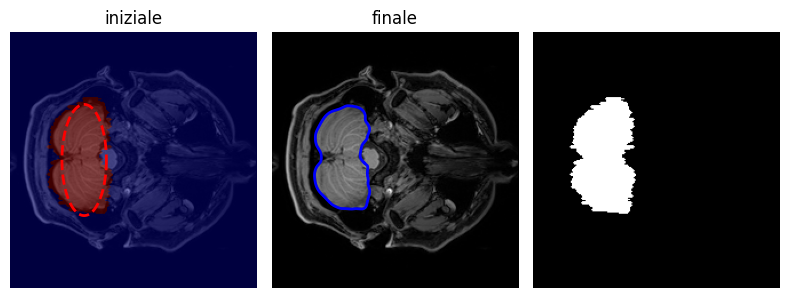

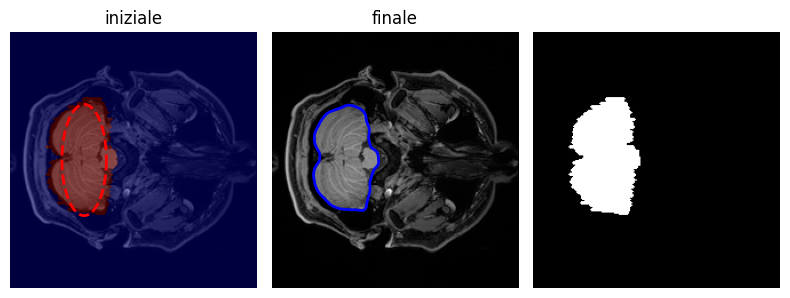

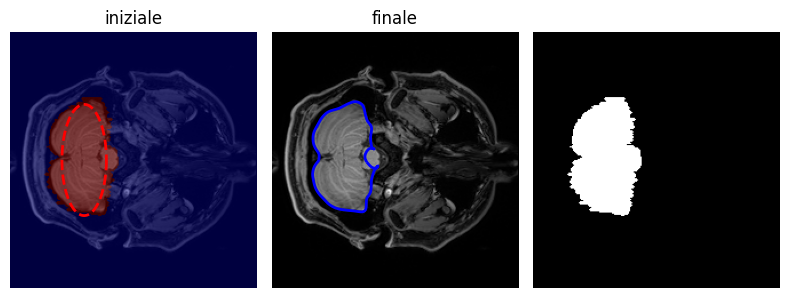

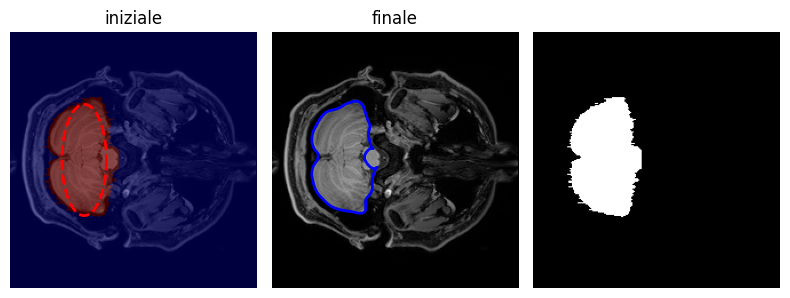

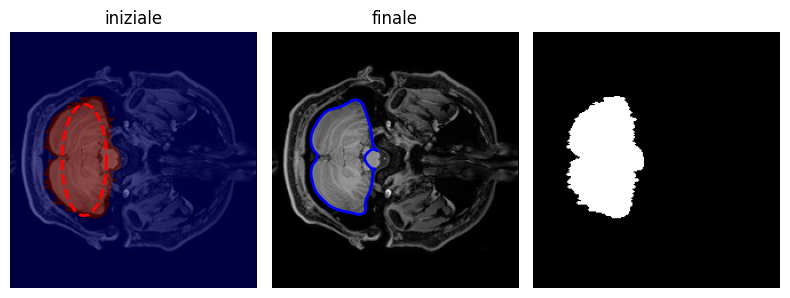

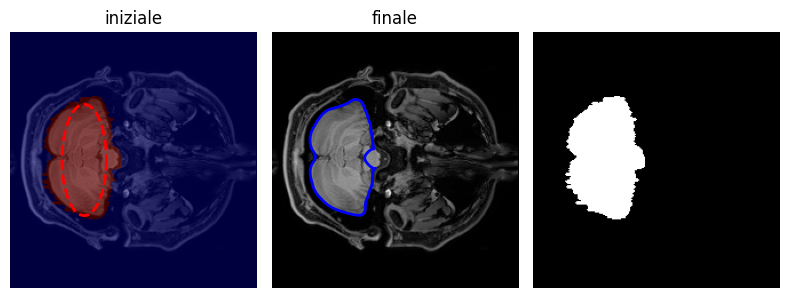

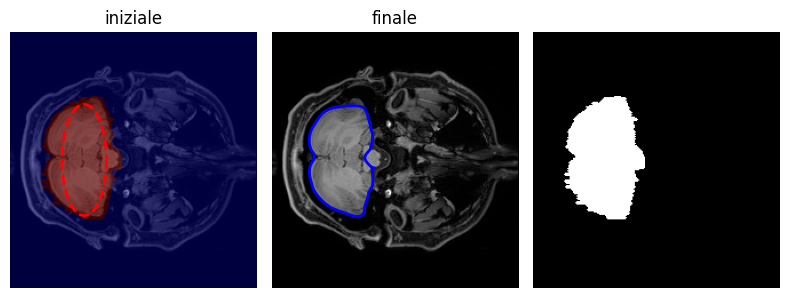

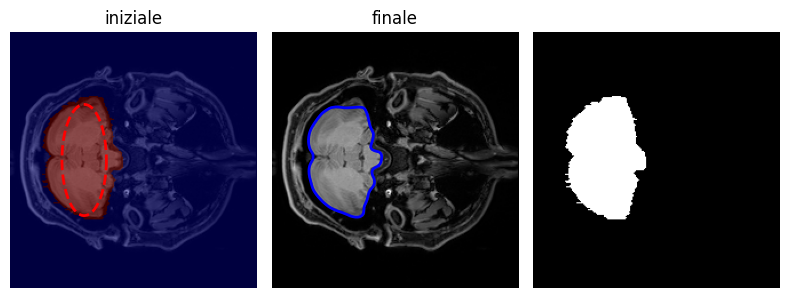

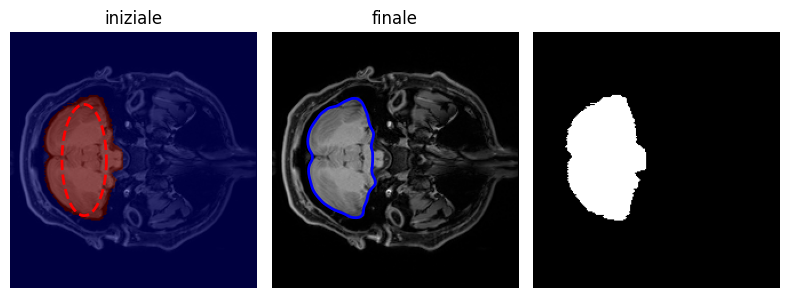

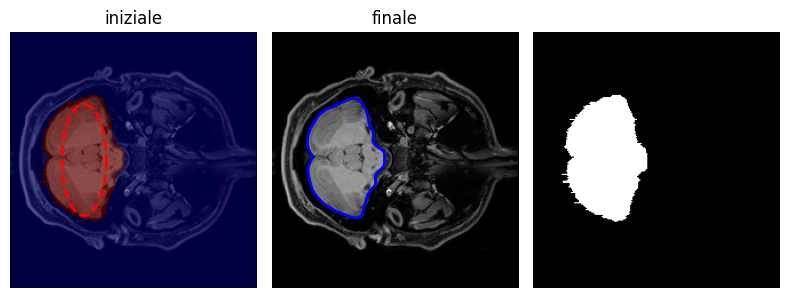

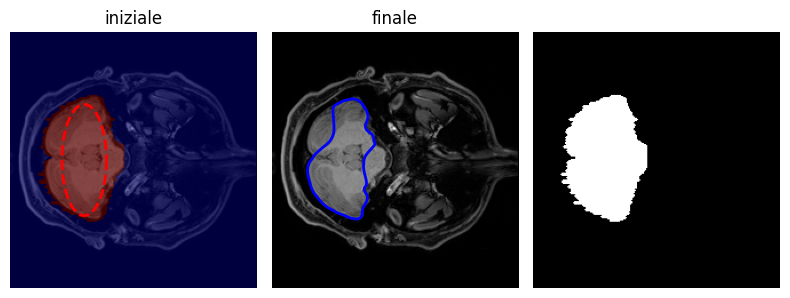

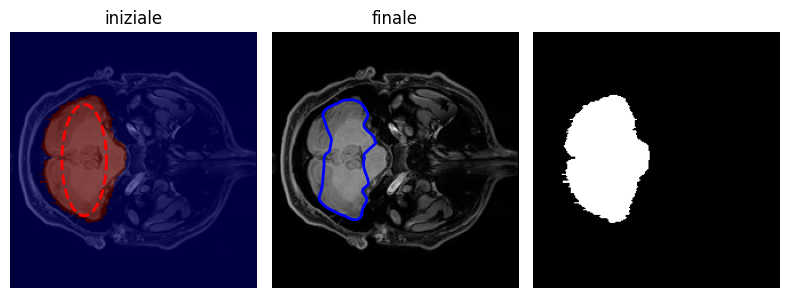

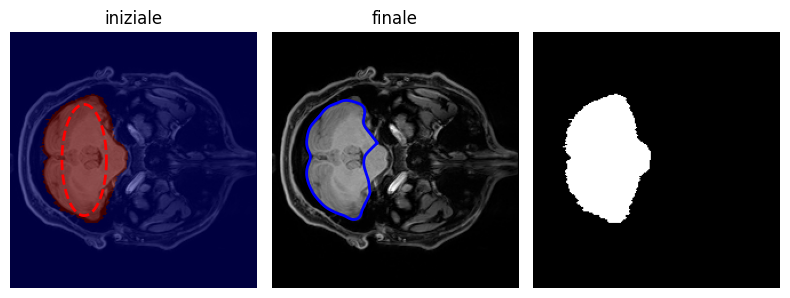

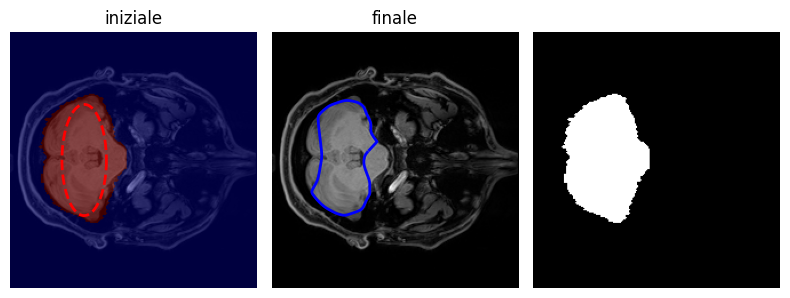

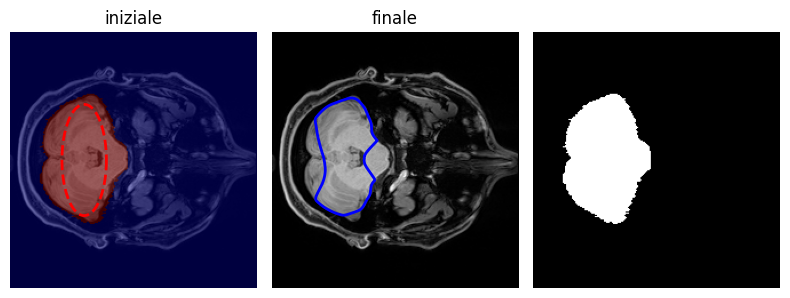

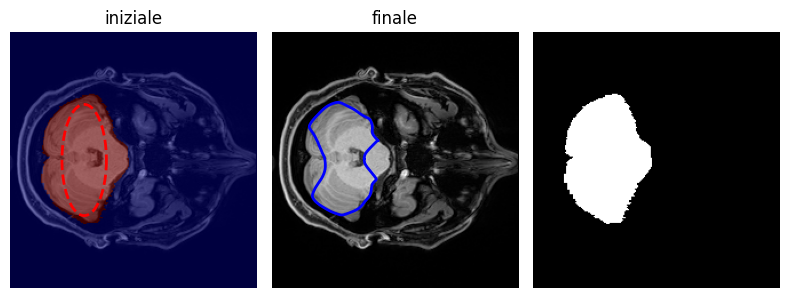

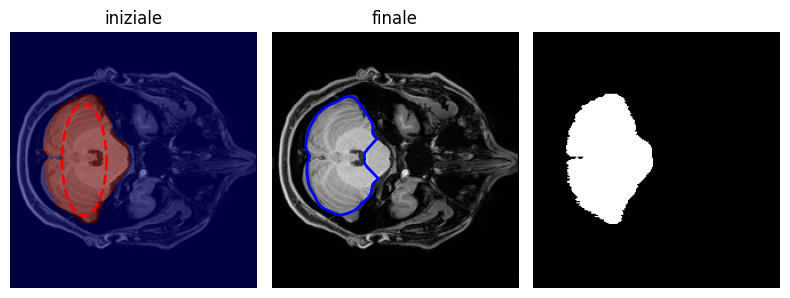

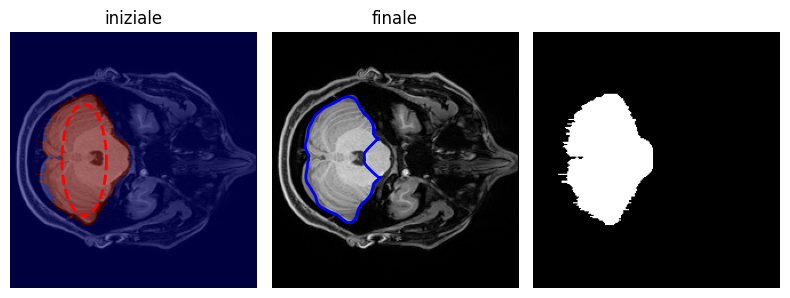

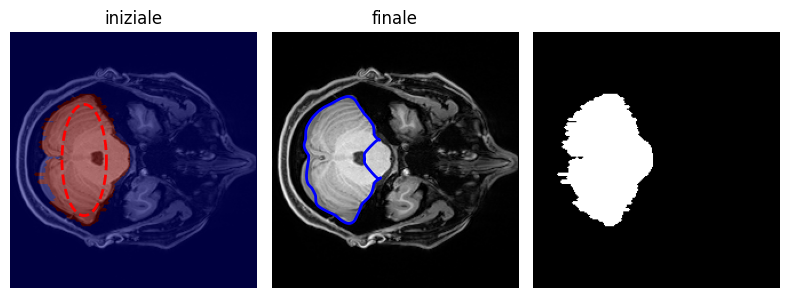

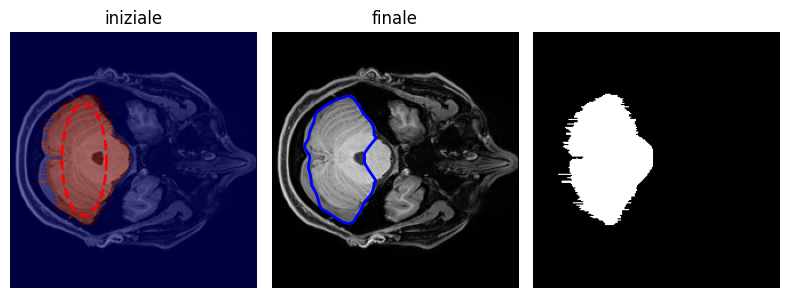

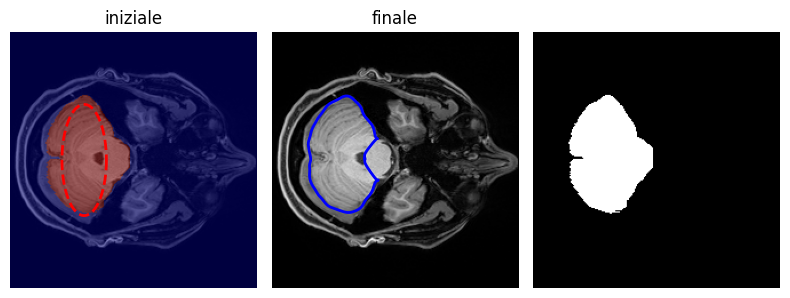

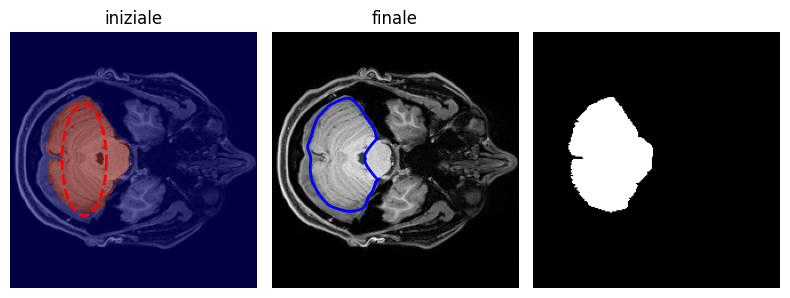

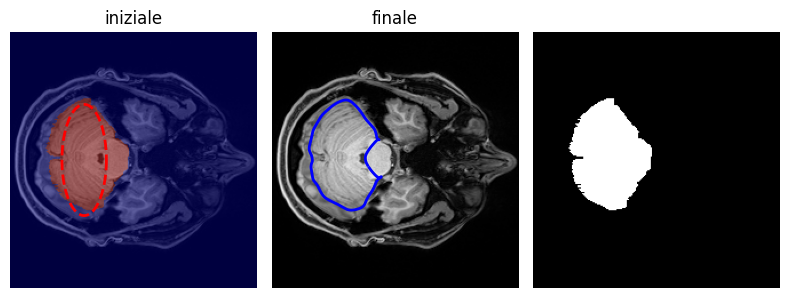

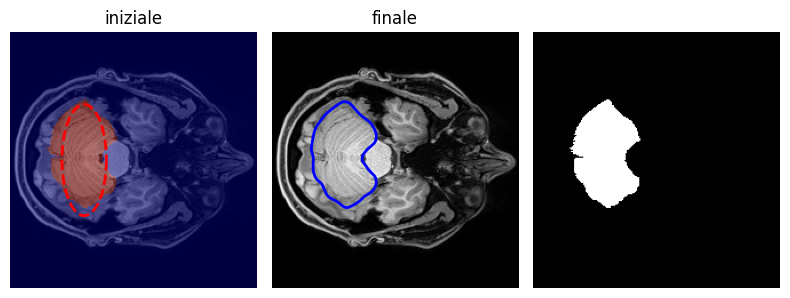

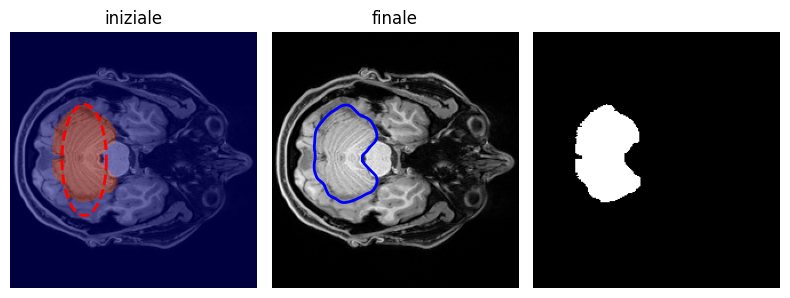

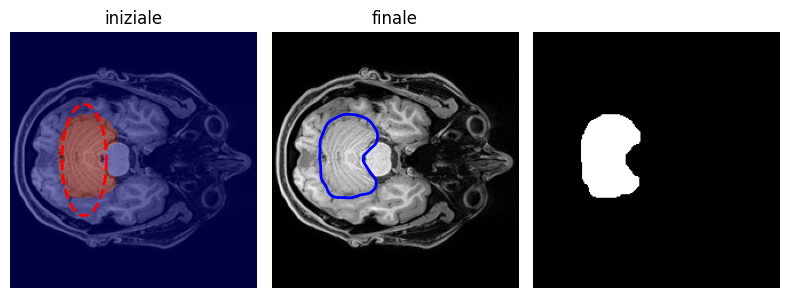

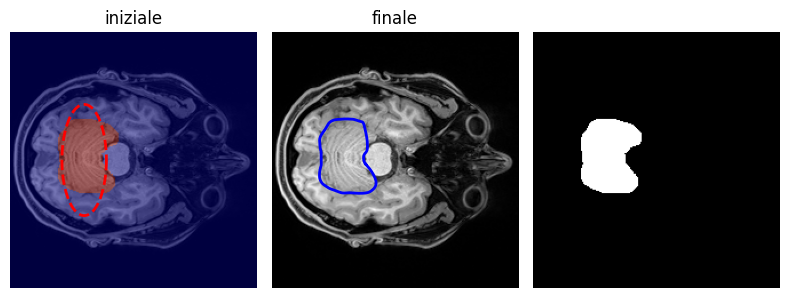

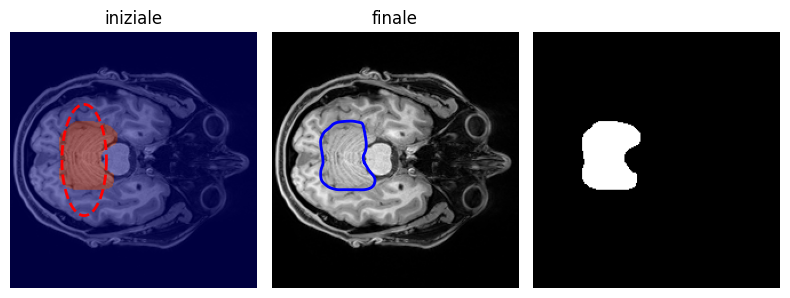

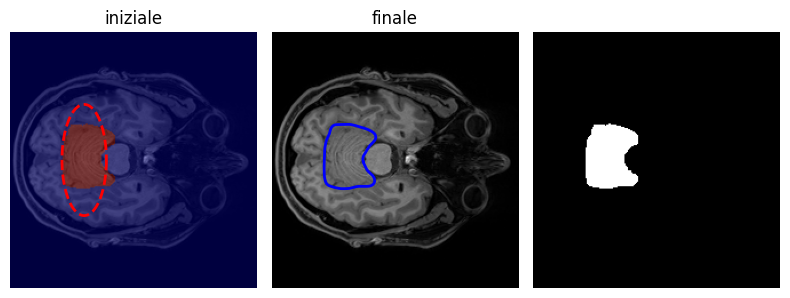

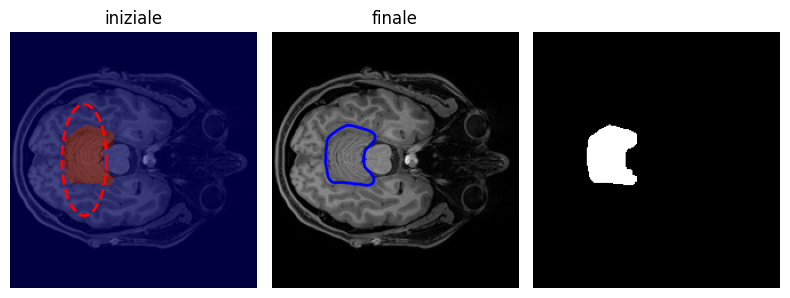

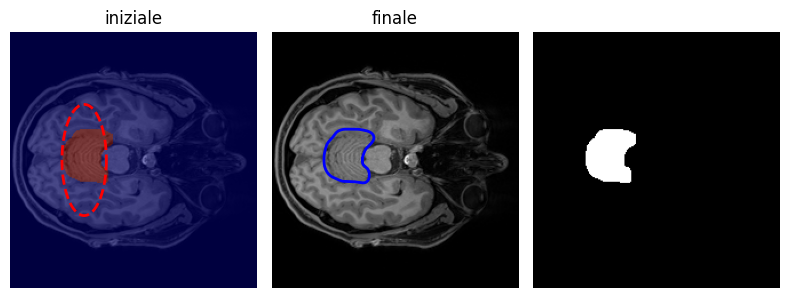

In [ ]:
# loop to print all of them
for slice_idx in slices_with_cerebellum:
    props = regionprops(labeled[:, :, slice_idx])
    y0 = props[0].centroid[0]                      # centro y
    x0 = props[0].centroid[1]                 # centro x (scala se necessario)
    major_axis_length = props[0].major_axis_length *1.2
    minor_axis_length = props[0].minor_axis_length *500

    # 2) Semi-assi
    ratio = 0.99
    radius1 = (major_axis_length / 2.0) * ratio    # semiasse verticale (asse y)
    radius2 = (minor_axis_length / 2.0) * ratio    # semiasse orizzontale (asse x)

    # 3) Costruisci la level-set dell’ellisse
    tmp = m[:, :, slice_idx]
    h, w = tmp.shape
    Y, X = np.ogrid[:h, :w]
    # criterio ellisse: ((y - y0)/radius1)^2 + ((x - x0)/radius2)^2 <= 1
    init_ls = (((Y - y0)**2) / radius1**2 + ((X - x0)**2) / radius2**2) <= 1
    init_ls = init_ls.astype(float)
    img = vol_mri[:, :, slice_idx]
    mask = m[:, :, slice_idx].astype(bool)

    # 2) azzera tutto ciò che è fuori dalla maschera
    img_masked = img.copy()
    img_masked[~mask] = 0

    # 3) do that onlu inside the mask
    img_f = gaussian(img_masked, sigma=2, preserve_range=False)

    # 4) calcola l’indicatore di bordo
    gimg = inverse_gaussian_gradient(img_f)


    snake = active_contour(
        img_f,      # o prova gimg
        init_pts,
        alpha=50,      # elasticità
        beta=50,      # rigidità
        gamma=50,    # passo
        w_edge=1.5,   # forza sul bordo
    )

    # 4) plottalo
    fig, axes = plt.subplots(1,3, figsize=(8,4))
    # Primo subplot
    axes[0].imshow(vol_mri[:,:,slice_idx], cmap='gray')
    axes[0].imshow(m[:,:,slice_idx], cmap='jet', alpha=0.5)  # <-- aggiunto qui sopra il primo
    axes[0].plot(init_pts[:,1], init_pts[:,0], 'r--', lw=2)
    axes[0].set_title("iniziale")
    # Secondo subplot
    axes[1].imshow(vol_mri[:,:,slice_idx], cmap='gray')
    axes[1].plot(snake[:,1], snake[:,0], 'b-',  lw=2)
    axes[1].set_title("finale")
    # Terzo subplot
    axes[2].imshow(m[:,:,slice_idx], cmap='gray')
    # Toglie assi
    for ax in axes:
        ax.axis('off')
    plt.tight_layout()
    plt.show()
    
    